работа будет с классическим датасетом о пингвинах с архипелага Палмер(ссылка - https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download)

In [1]:
import pandas as pd
import numpy as np
import missingno as mgno
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("penguins_lter.csv")

In [3]:
df

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/1/09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN


Пункт А)Быстрый обзор данных (Pandas)

In [4]:
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [5]:
df.tail()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/1/09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN
343,PAL0910,124,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A2,Yes,11/22/09,49.9,16.1,213.0,5400.0,MALE,8.36390,-26.15531,NaN


In [6]:
df.shape

(344, 17)

In [7]:
df.info

<bound method DataFrame.info of     studyName  Sample Number                              Species  Region  \
0     PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1     PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2     PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3     PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4     PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   
..        ...            ...                                  ...     ...   
339   PAL0910            120    Gentoo penguin (Pygoscelis papua)  Anvers   
340   PAL0910            121    Gentoo penguin (Pygoscelis papua)  Anvers   
341   PAL0910            122    Gentoo penguin (Pygoscelis papua)  Anvers   
342   PAL0910            123    Gentoo penguin (Pygoscelis papua)  Anvers   
343   PAL0910            124    Gentoo penguin (Pygoscelis papua)  Anvers   

        Island               Stage Individu

In [8]:
df.describe()

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


In [9]:
df.describe(include="object")

/tmp/ipykernel_13445/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,studyName,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Sex,Comments
count,344,344,344,344,344,344,344,344,334,26
unique,3,3,1,3,1,190,2,50,3,7
top,PAL0910,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N6A1,Yes,11/27/07,MALE,Nest never observed with full clutch.
freq,120,152,344,168,344,3,308,18,168,13


Пункт Б)Пропуски и очистка

DropNA будем использовать в случае когда у нас почти все числовые данные утеряны, в строке 3-4 Na, также для обработки данных стоит убрать комментарии, и отдельно проанализировать при необходимости

In [10]:
df_clean1 = df.drop(columns = ["Comments"])
df_clean1 = df_clean1.dropna(thresh = 12)

<Axes: >

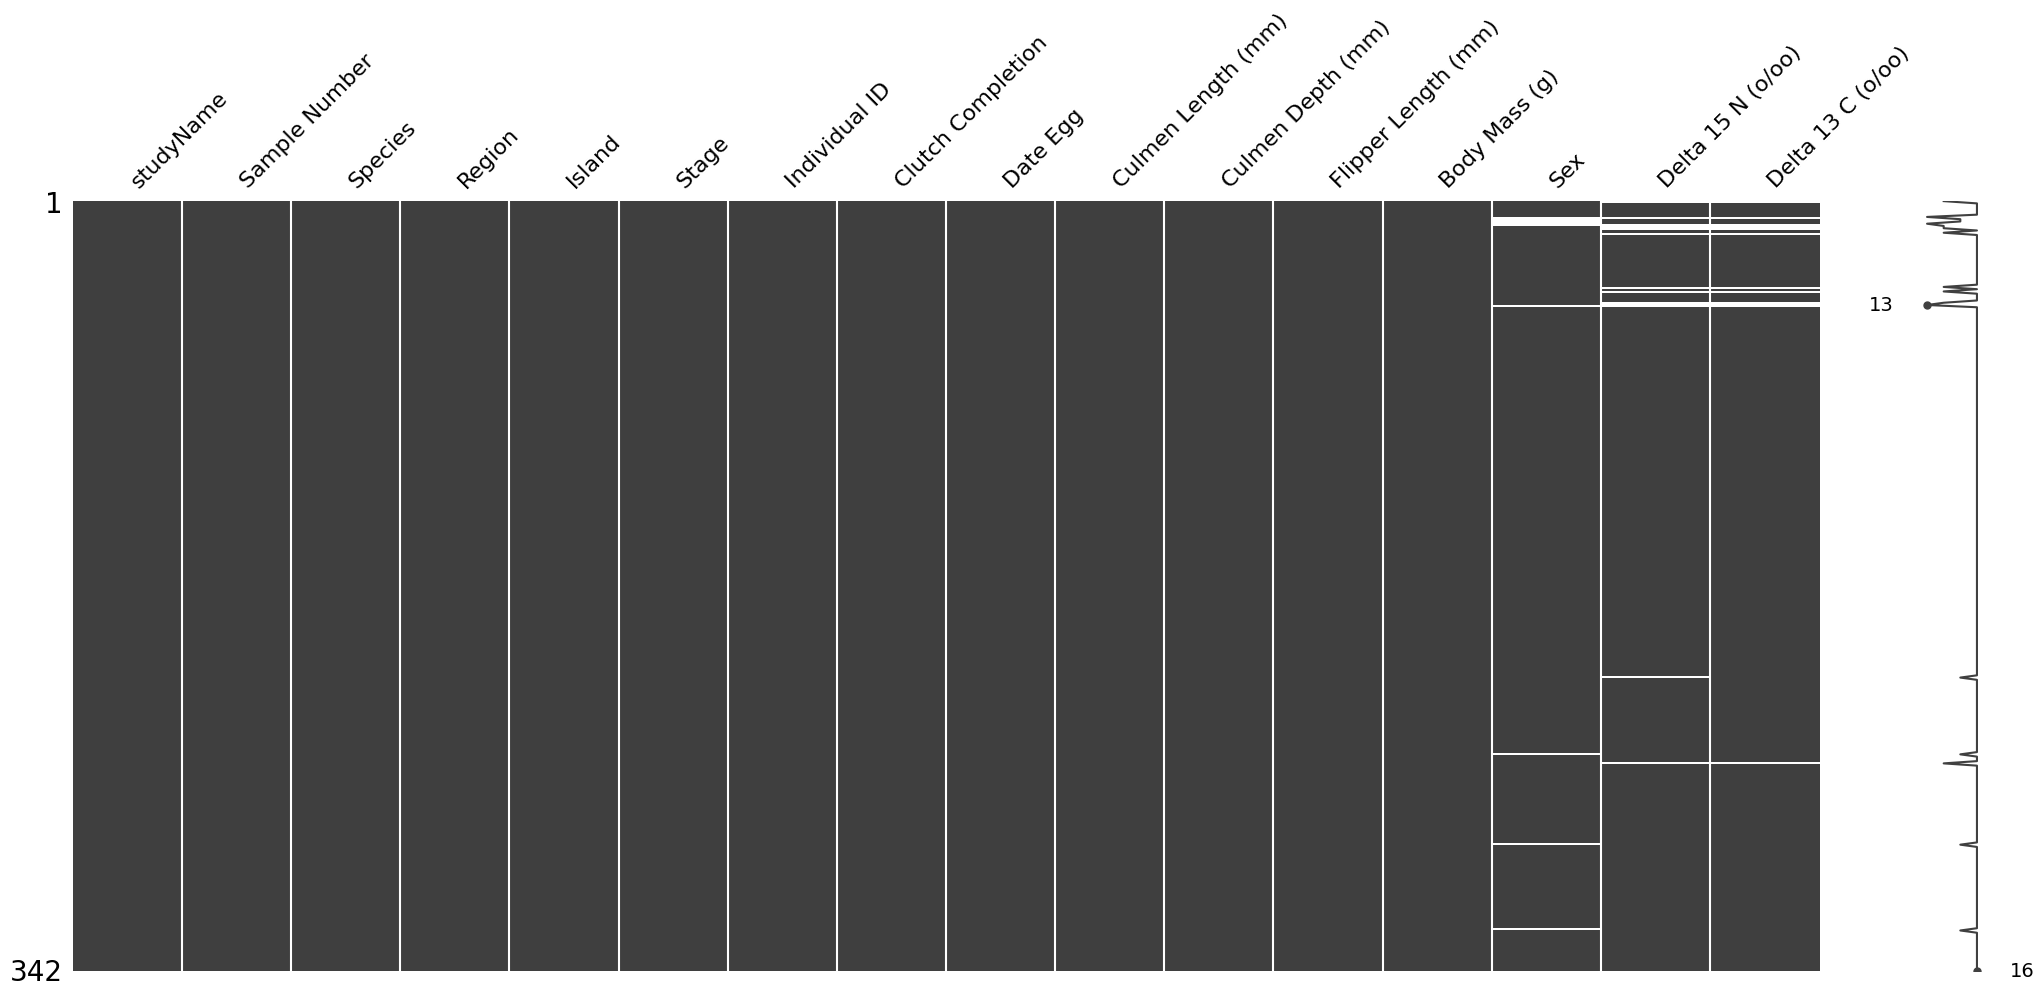

In [11]:
mgno.matrix(df_clean1)

Использую missingno для простой визуализации в каких столбцах у нас остались NA и с чем будем работать 

In [12]:
df_clean1.describe()

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,342.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.157895,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.304467,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.250000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.000000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


все кроме пола(количество изотопов в крови) имеет смысл заменить средним т.к.у признака низкое стандартное отклонение(меньше 1) и это просто первое что приходит на ум

In [13]:
df_formean15N = df_clean1["Delta 15 N (o/oo)"].dropna()
df_formean13C = df_clean1["Delta 13 C (o/oo)"].dropna()

mean15N = df_formean15N.mean()
mean13C = df_formean13C.mean()
print(mean15N,mean13C)

8.733381696969698 -25.686291540785504


In [14]:
df_clean1["Delta 15 N (o/oo)"] = df_clean1["Delta 15 N (o/oo)"].fillna(mean15N)
df_clean1["Delta 13 C (o/oo)"] = df_clean1["Delta 13 C (o/oo)"].fillna(mean13C)

<Axes: >

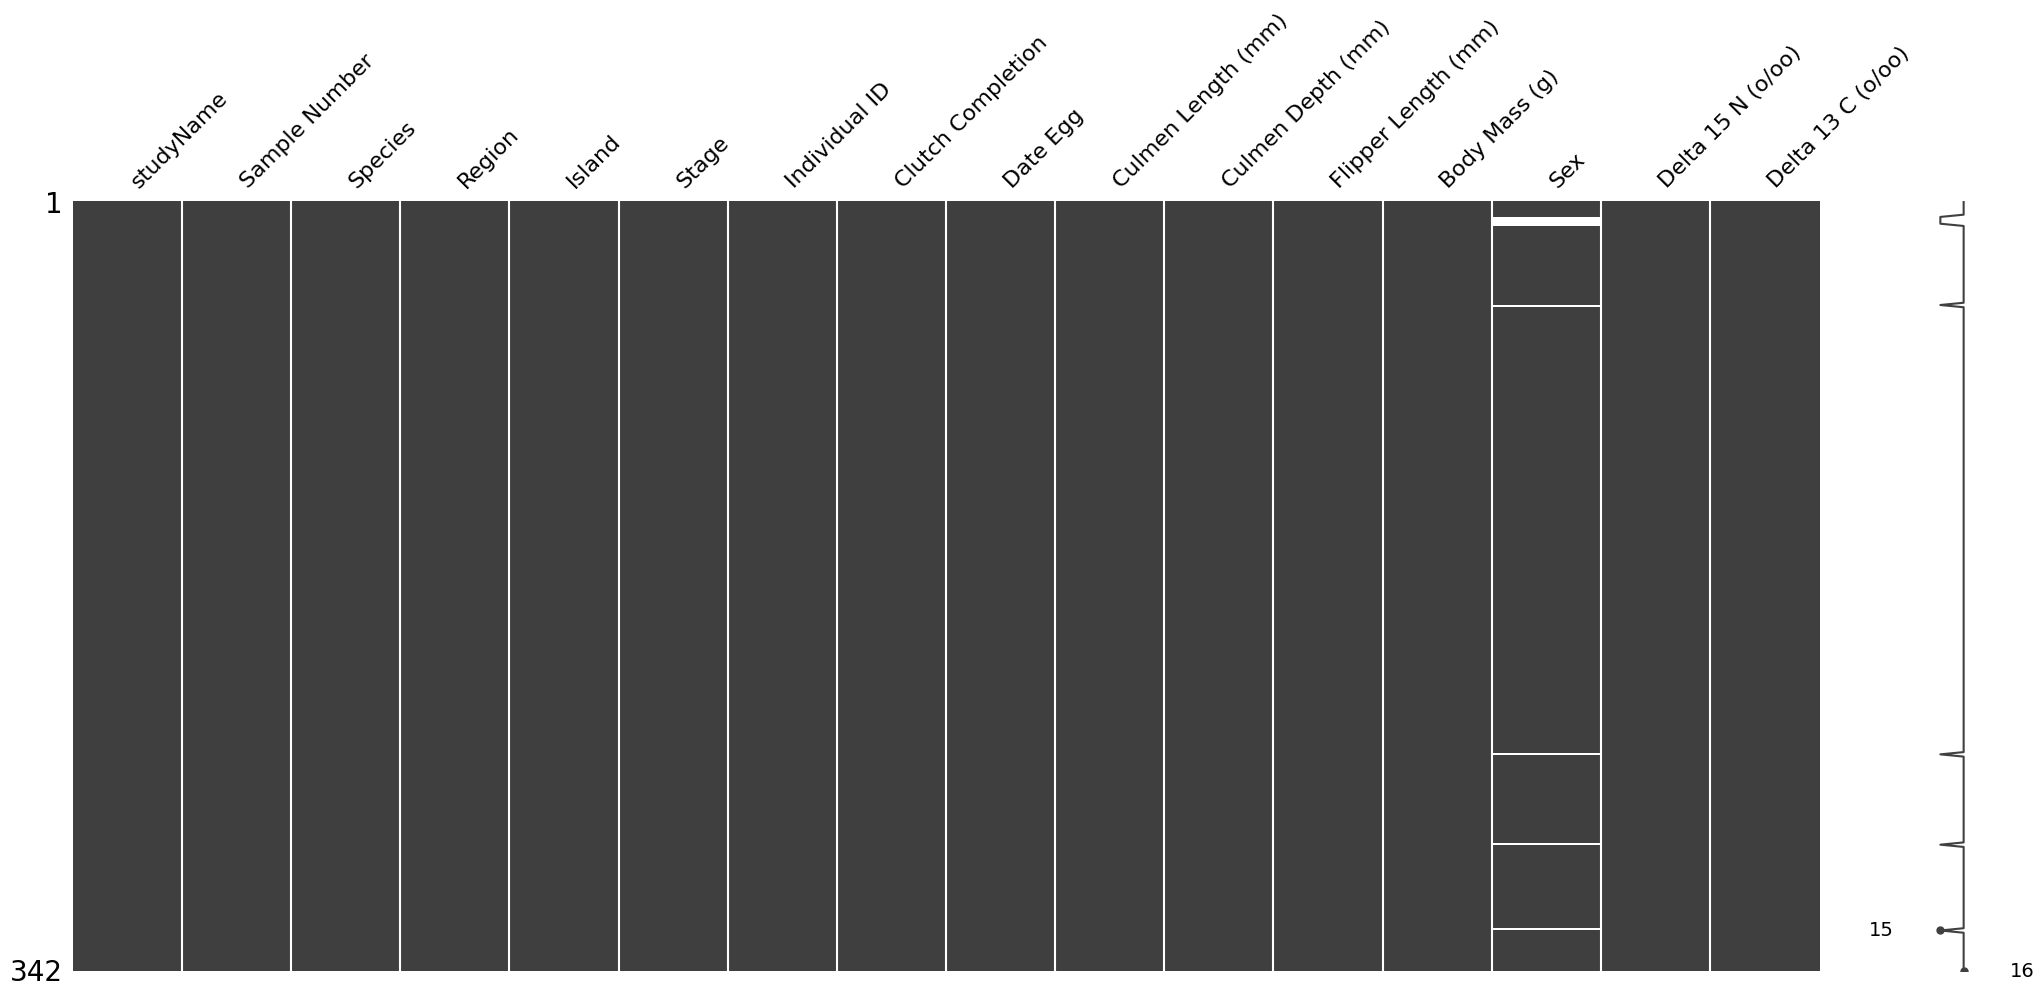

In [15]:
mgno.matrix(df_clean1)

с полом все не так просто т.к. эта характеристика как известно из общей биологии влияет на массу,так что задача по восстановлению пола является задачей для бинарной классификации и я бы эту задачу решал с помощью модели машинного обучения, что оставим на третье домашнее задание, где с помощью KNN будем пытаться востанавить данные, а сейчас просто рандомом

In [16]:
df_clean1.mode()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,PAL0910,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N13A1,Yes,11/27/07,41.1,17.0,190.0,3800.0,MALE,8.733382,-25.686292
1,NaN,2,NaN,NaN,NaN,NaN,N13A2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,3,NaN,NaN,NaN,NaN,N18A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,5,NaN,NaN,NaN,NaN,N18A2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,6,NaN,NaN,NaN,NaN,N21A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,NaN,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,NaN,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C)Расширенная статистика

In [17]:
numeric_df_data = df_clean1.select_dtypes(include="number")
numeric_df_data

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
0,1,39.1,18.7,181.0,3750.0,8.733382,-25.686292
1,2,39.5,17.4,186.0,3800.0,8.949560,-24.694540
2,3,40.3,18.0,195.0,3250.0,8.368210,-25.333020
4,5,36.7,19.3,193.0,3450.0,8.766510,-25.324260
5,6,39.3,20.6,190.0,3650.0,8.664960,-25.298050
...,...,...,...,...,...,...,...
338,119,47.2,13.7,214.0,4925.0,7.991840,-26.205380
340,121,46.8,14.3,215.0,4850.0,8.411510,-26.138320
341,122,50.4,15.7,222.0,5750.0,8.301660,-26.041170
342,123,45.2,14.8,212.0,5200.0,8.242460,-26.119690


In [18]:
numeric_df_data.describe() #стоит сказать что числовая обработка колонок с номером образца не имеет особо смысла, т.к. этот столбец имеет больше категориальную функцию

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,63.157895,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.304467,5.459584,1.974793,14.061714,801.954536,0.541975,0.781050
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.250000,39.225000,15.600000,190.000000,3550.000000,8.305905,-26.295280
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.681410,-25.795390
75%,95.000000,48.500000,18.700000,213.000000,4750.000000,9.141270,-25.081043
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


теперь посчитаем квантили

In [19]:
numeric_df_data.quantile(0.33)

Sample Number            38.530000
Culmen Length (mm)       40.753000
Culmen Depth (mm)        16.153000
Flipper Length (mm)     192.000000
Body Mass (g)          3700.000000
Delta 15 N (o/oo)         8.437028
Delta 13 C (o/oo)       -26.156457
Name: 0.33, dtype: float64

In [20]:
numeric_df_data.quantile(0.95)

Sample Number           134.950000
Culmen Length (mm)       51.995000
Culmen Depth (mm)        20.000000
Flipper Length (mm)     225.000000
Body Mass (g)          5650.000000
Delta 15 N (o/oo)         9.688125
Delta 13 C (o/oo)       -24.363295
Name: 0.95, dtype: float64

In [21]:
numeric_df_data.quantile(0.05)

Sample Number             7.000000
Culmen Length (mm)       35.700000
Culmen Depth (mm)        13.900000
Flipper Length (mm)     181.000000
Body Mass (g)          3150.000000
Delta 15 N (o/oo)         7.897786
Delta 13 C (o/oo)       -26.789468
Name: 0.05, dtype: float64

In [22]:
numeric_df_data.var()#среднеквадратичное отклонение от среднего, со степенями свободы  N-1, т.е. квадрат того насколько сильно в среднем отклоняются данные

Sample Number            1624.450069
Culmen Length (mm)         29.807054
Culmen Depth (mm)           3.899808
Flipper Length (mm)       197.731792
Body Mass (g)          643131.077327
Delta 15 N (o/oo)           0.293737
Delta 13 C (o/oo)           0.610040
dtype: float64

In [23]:
numeric_df_data.skew() # то насколько наше распределение не симметрично, 
# 0 как нормальное распредление слева и справа от центра одинаково, при этом мода и медиана совпадает, <0 будет большще влево смещен график, а  >0 вправо

Sample Number          0.357337
Culmen Length (mm)     0.053118
Culmen Depth (mm)     -0.143465
Flipper Length (mm)    0.345682
Body Mass (g)          0.470329
Delta 15 N (o/oo)      0.243248
Delta 13 C (o/oo)      0.343298
dtype: float64

In [24]:
numeric_df_data.kurt() #показывает склоность распределения данных к появлению выбросов, чем меньше значение тем меньше склонность к выбросам

Sample Number         -0.913069
Culmen Length (mm)    -0.876027
Culmen Depth (mm)     -0.906866
Flipper Length (mm)   -0.984273
Body Mass (g)         -0.719222
Delta 15 N (o/oo)     -0.665475
Delta 13 C (o/oo)     -0.964214
dtype: float64

D)  D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)
начем с того что представим пол  в формате нулей и единиц,
используем OHE  для видов и островов

In [25]:
df_clean1["Sex"] = (df_clean1["Sex"] == "FEMALE").astype(int)
df_clean1

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,0,8.733382,-25.686292
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,1,8.949560,-24.694540
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,1,8.368210,-25.333020
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,1,8.766510,-25.324260
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,0,8.664960,-25.298050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,PAL0910,119,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A1,No,12/1/09,47.2,13.7,214.0,4925.0,1,7.991840,-26.205380
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,1,8.411510,-26.138320
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,0,8.301660,-26.041170
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,1,8.242460,-26.119690


теперь используем OHE для "Island" и "Species", регион и стадию можно опустить,т.к. встречается только одно и то же значение признака

In [26]:
enc = ["Island"]
df_OHE_encoded = pd.get_dummies(df_clean1, columns = enc, dtype = int, drop_first = True)
df_OHE_encoded
df_OH_encoded = df_OHE_encoded.drop(columns = ["Region","Stage"])
df_OH_encoded

,studyName,Sample Number,Species,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,0,8.733382,-25.686292,0,1
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,1,8.949560,-24.694540,0,1
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,1,8.368210,-25.333020,0,1
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,1,8.766510,-25.324260,0,1
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,0,8.664960,-25.298050,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,PAL0910,119,Gentoo penguin (Pygoscelis papua),N38A1,No,12/1/09,47.2,13.7,214.0,4925.0,1,7.991840,-26.205380,0,0
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,1,8.411510,-26.138320,0,0
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,0,8.301660,-26.041170,0,0
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,1,8.242460,-26.119690,0,0


создадим теперь новые фичи, первая например Culmen Length/Depth ratio , а также соотношение длинны длины плавников к массе

In [27]:
df = df_OH_encoded.assign(C = df_OH_encoded["Culmen Length (mm)"]/df_OH_encoded["Culmen Depth (mm)"])
df = df.assign(D = df_OH_encoded["Flipper Length (mm)"]/df_OH_encoded["Body Mass (g)"])
df = df.rename(columns = {"C":"Culmen Length/Depth ratio", "D":"Flipper Length/Mass ratio"})
df

,studyName,Sample Number,Species,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Culmen Length/Depth ratio,Flipper Length/Mass ratio
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,0,8.733382,-25.686292,0,1,2.090909,0.048267
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,1,8.949560,-24.694540,0,1,2.270115,0.048947
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,1,8.368210,-25.333020,0,1,2.238889,0.060000
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,1,8.766510,-25.324260,0,1,1.901554,0.055942
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,0,8.664960,-25.298050,0,1,1.907767,0.052055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,PAL0910,119,Gentoo penguin (Pygoscelis papua),N38A1,No,12/1/09,47.2,13.7,214.0,4925.0,1,7.991840,-26.205380,0,0,3.445255,0.043452
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,1,8.411510,-26.138320,0,0,3.272727,0.044330
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,0,8.301660,-26.041170,0,0,3.210191,0.038609
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,1,8.242460,-26.119690,0,0,3.054054,0.040769


Пункт E) визуализация

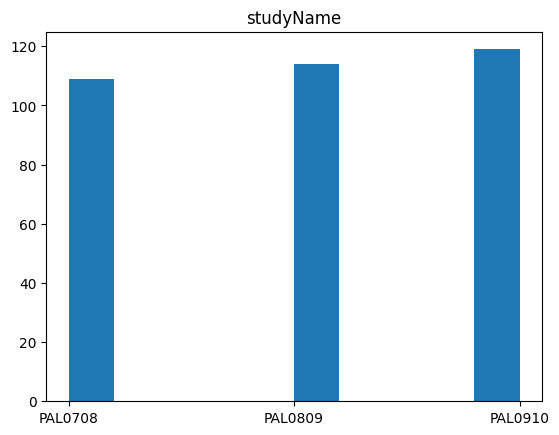

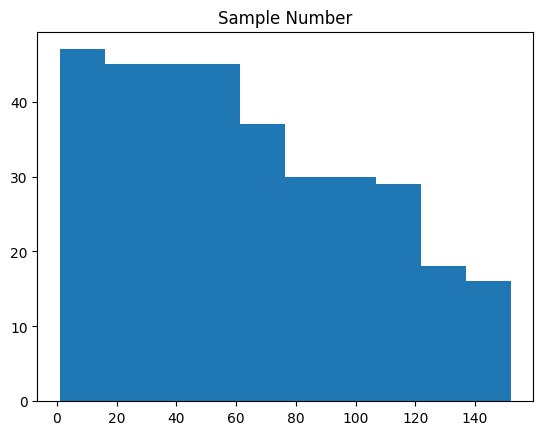

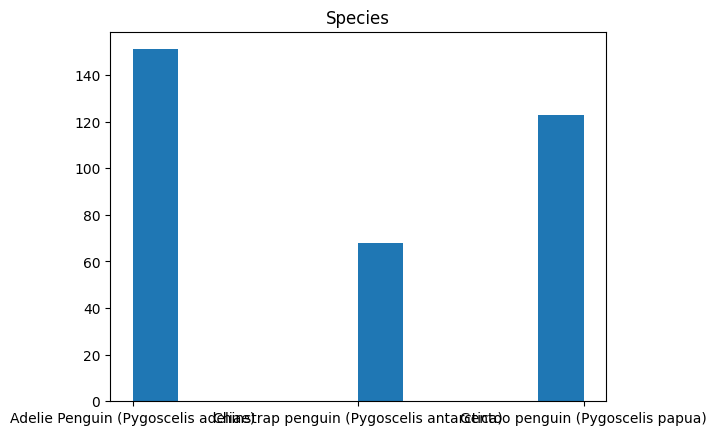

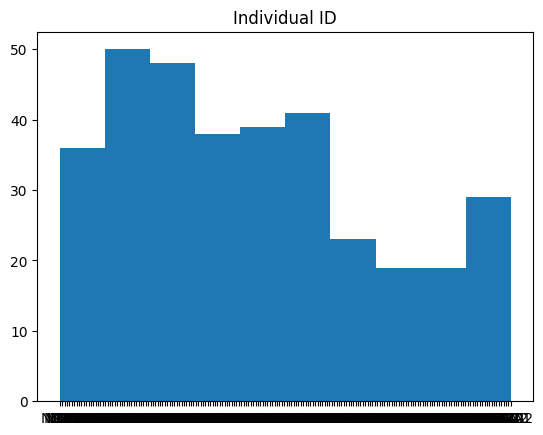

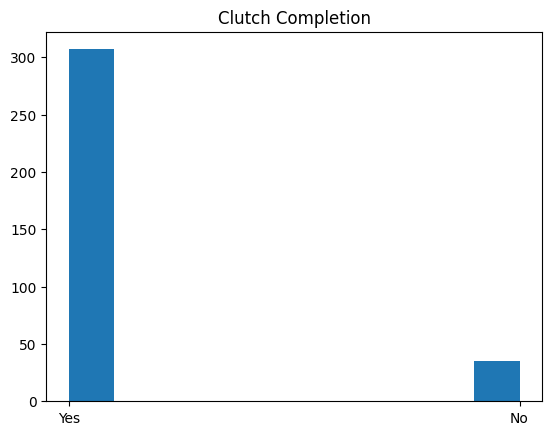

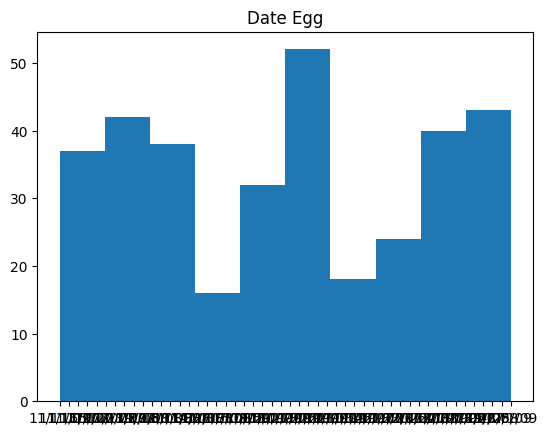

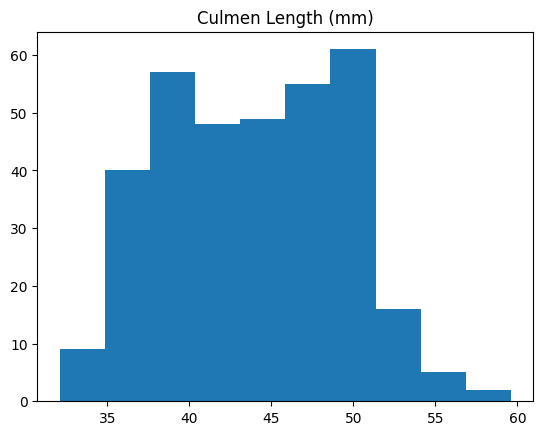

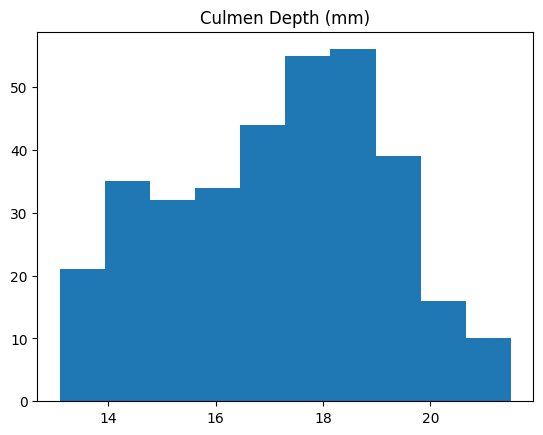

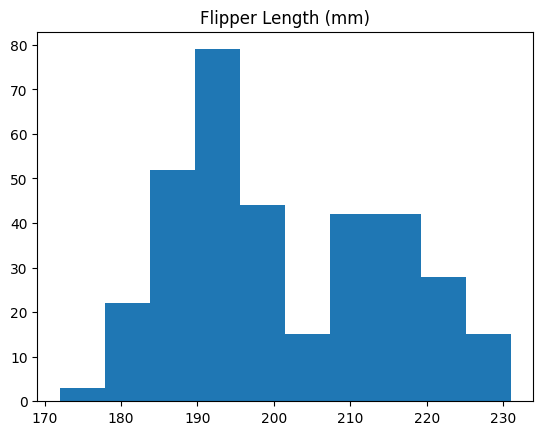

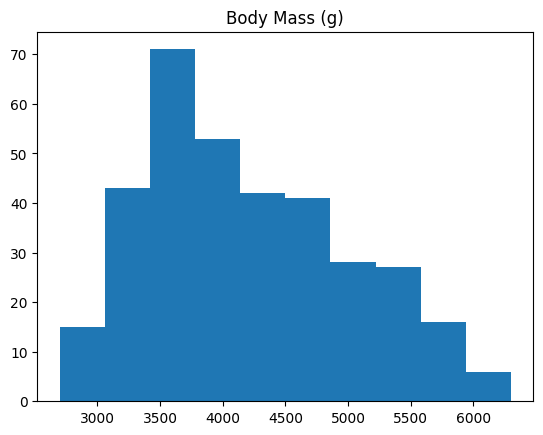

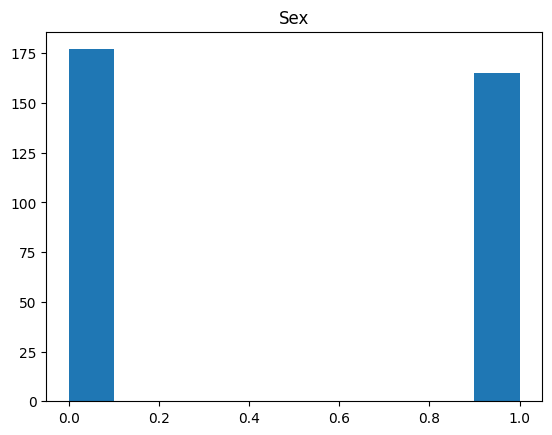

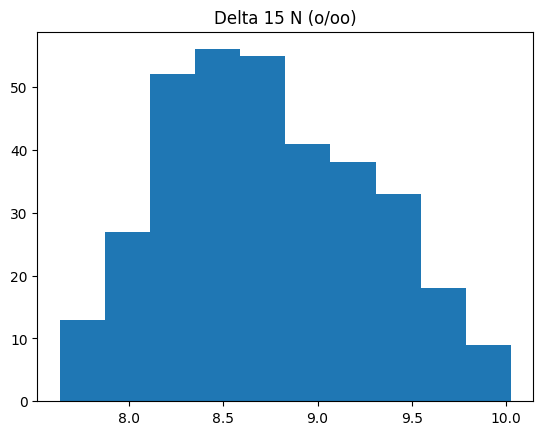

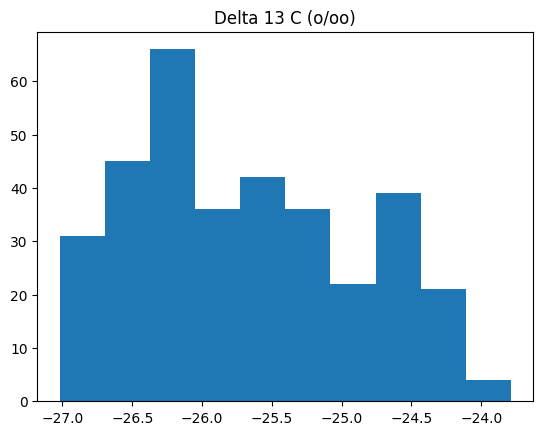

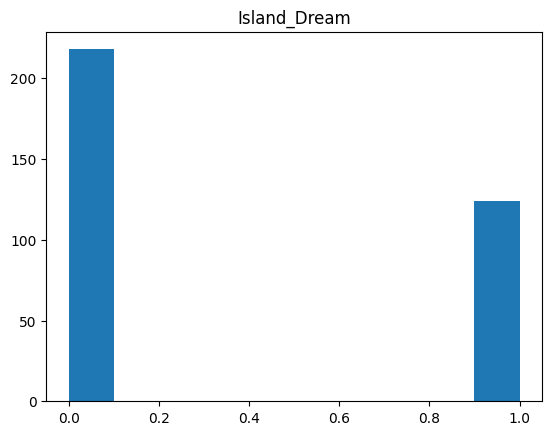

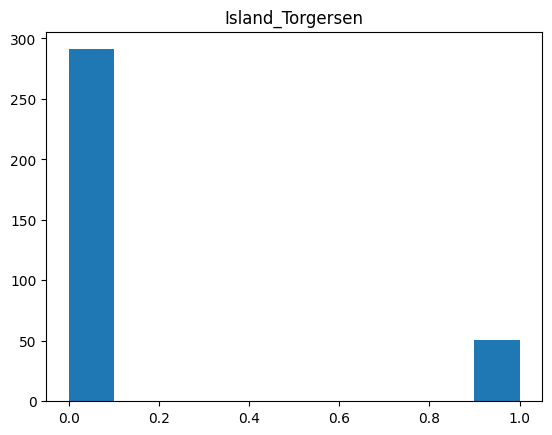

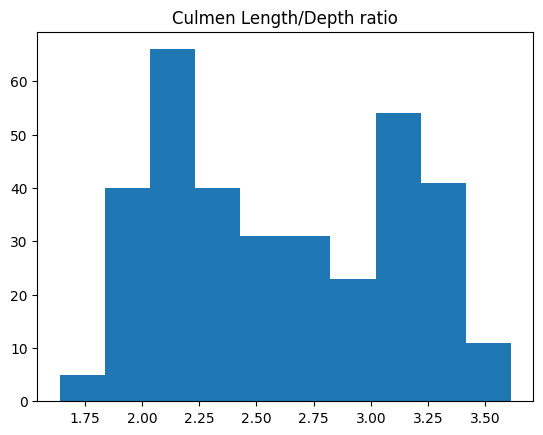

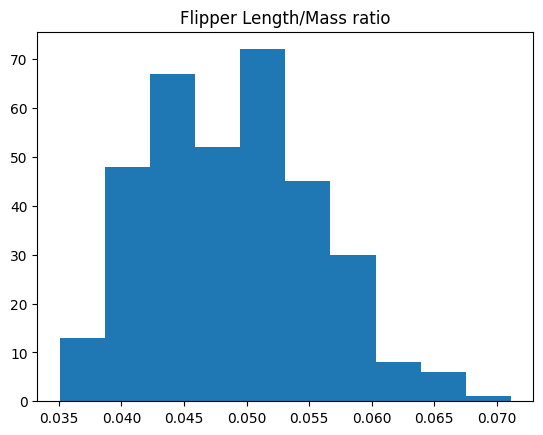

In [28]:
for i in df.columns :
    plt.figure()
    plt.title(i)
    plt.hist(df[i] )
    plt.tight_layout

In [29]:
df_visFRQ = df.drop(columns = ["Individual ID","Date Egg"])
df_visFRQ.columns

Index(['studyName', 'Sample Number', 'Species', 'Clutch Completion',
       'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
       'Body Mass (g)', 'Sex', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)',
       'Island_Dream', 'Island_Torgersen', 'Culmen Length/Depth ratio',
       'Flipper Length/Mass ratio'],
      dtype='str')

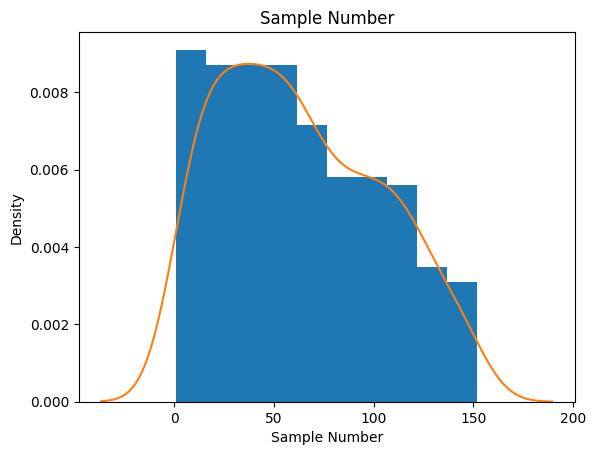

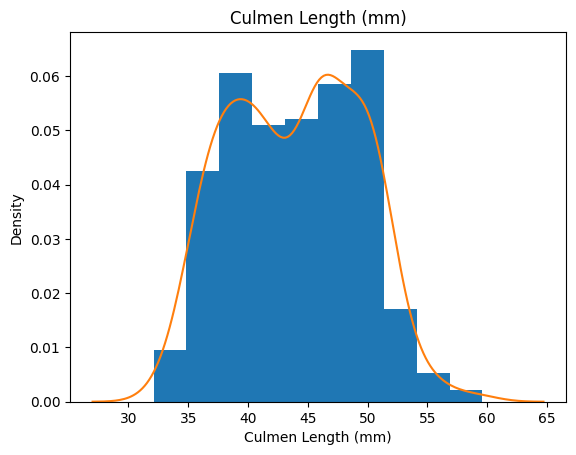

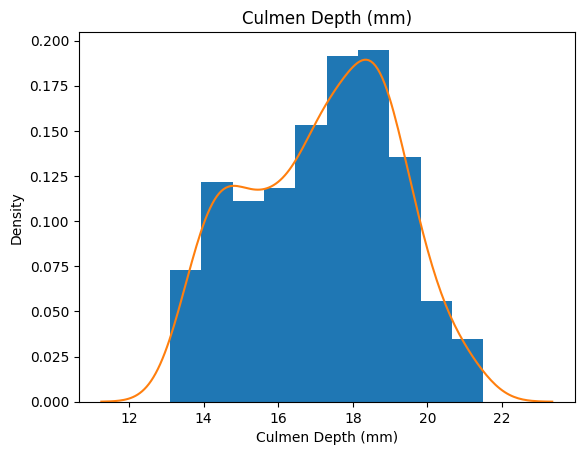

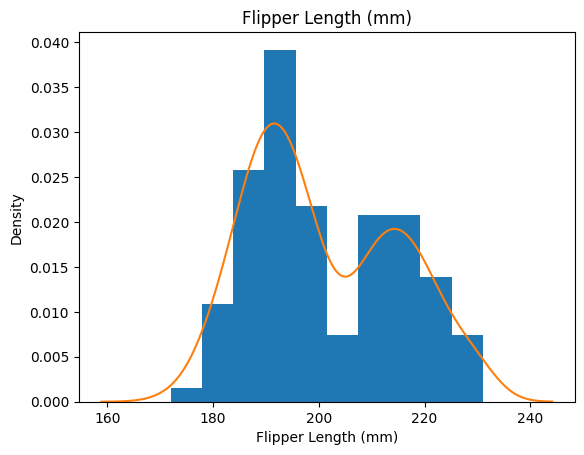

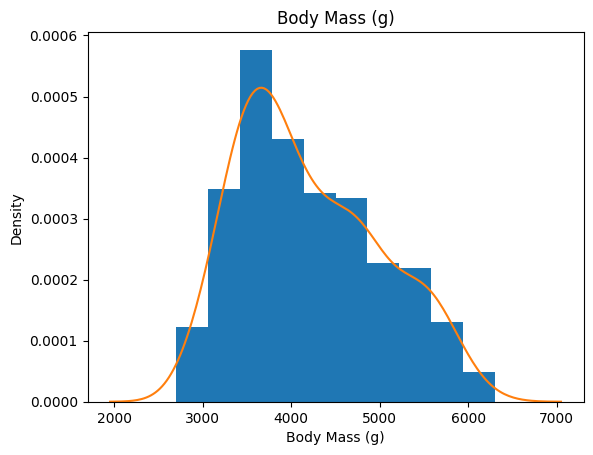

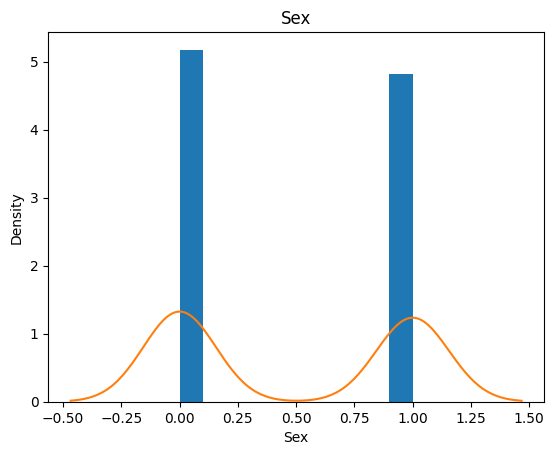

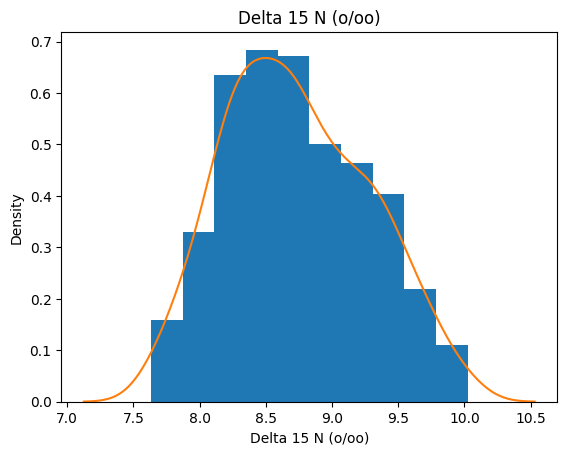

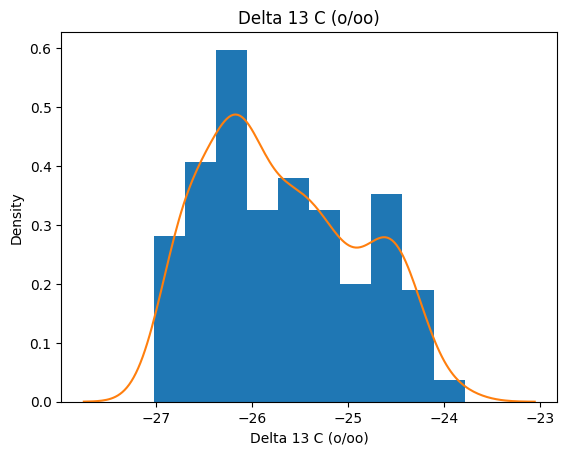

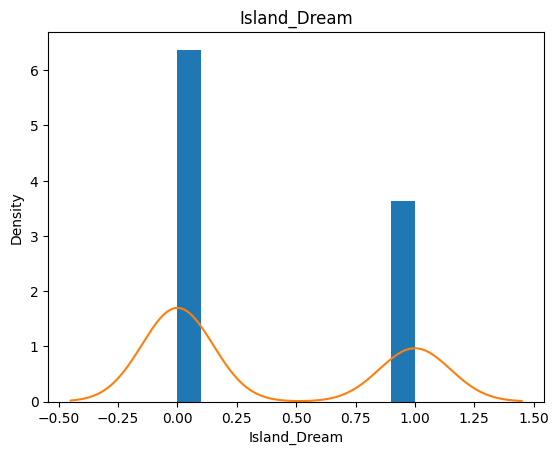

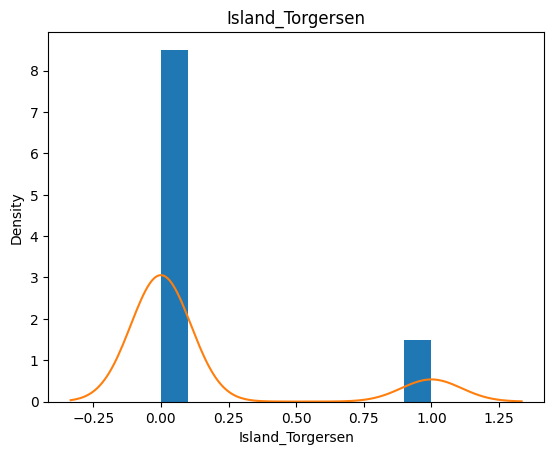

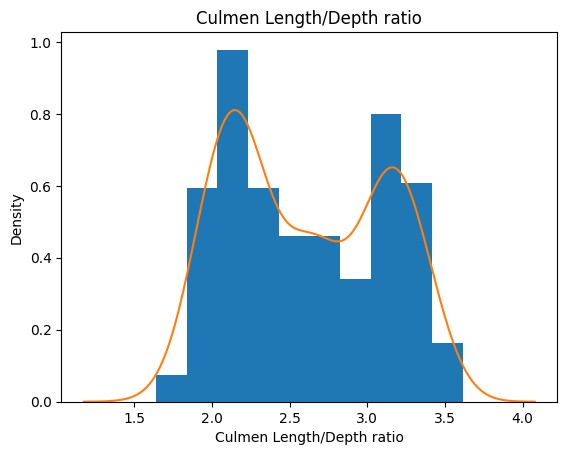

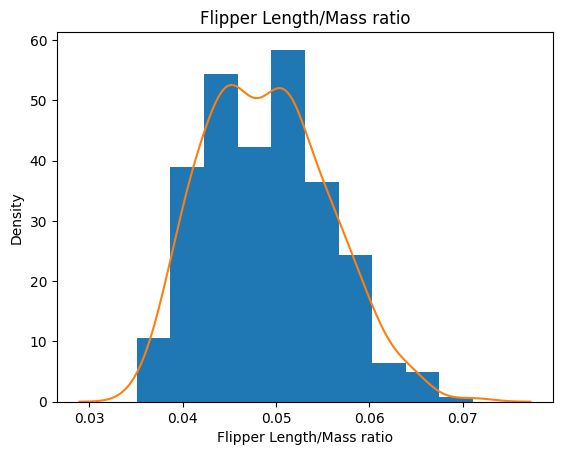

In [30]:
import seaborn as sns
from pandas.api.types import is_numeric_dtype

for i in df_visFRQ.columns :
    if is_numeric_dtype(df_visFRQ[i]) :
        plt.figure()
        plt.title(i)
        plt.hist(df[i], density = True)
        sns.kdeplot(df_visFRQ[i])

Скаттер плот подходит для того чтобы искать зависимость между двумя разными числовыми признаками

Text(0.5, 1.0, 'Flipper Length depending on body mass')

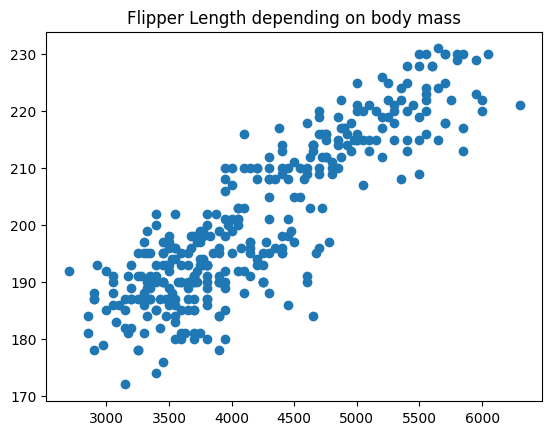

In [31]:
x = df["Body Mass (g)"]
y = df["Flipper Length (mm)"]
plt.figure()
plt.scatter(x,y)
plt.title("Flipper Length depending on body mass")

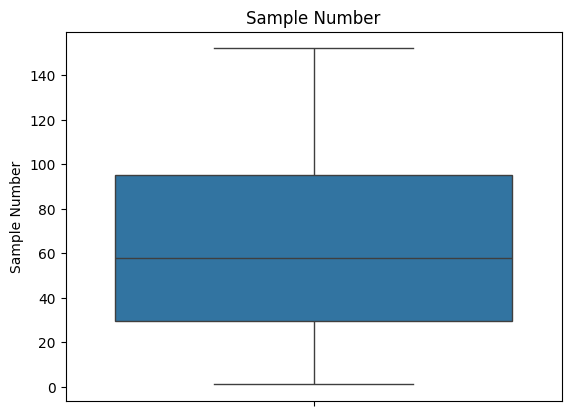

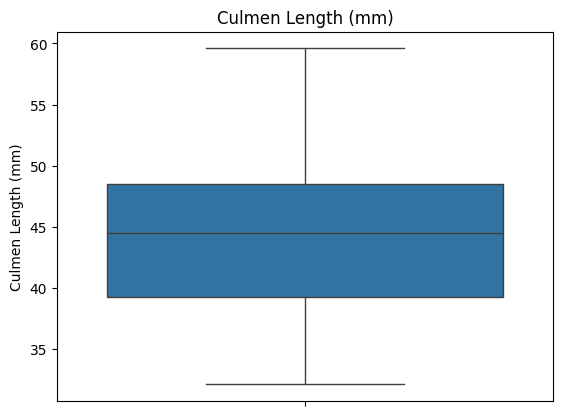

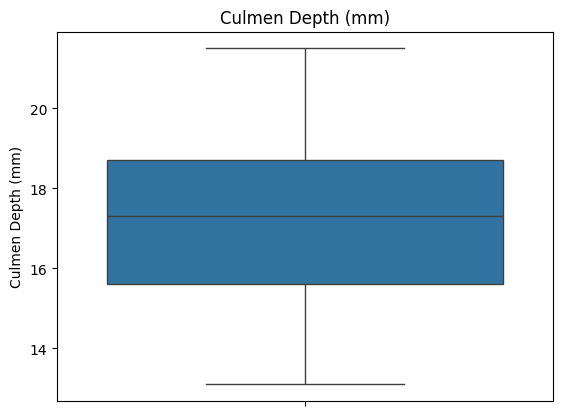

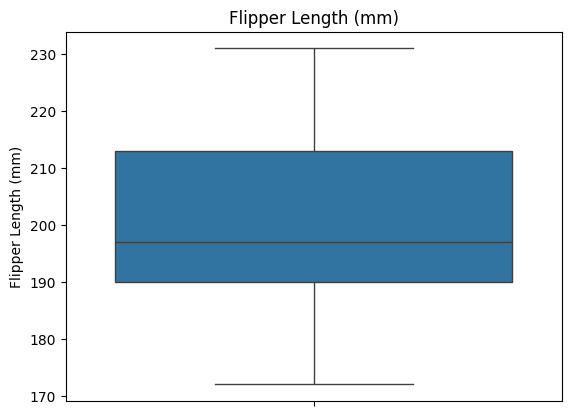

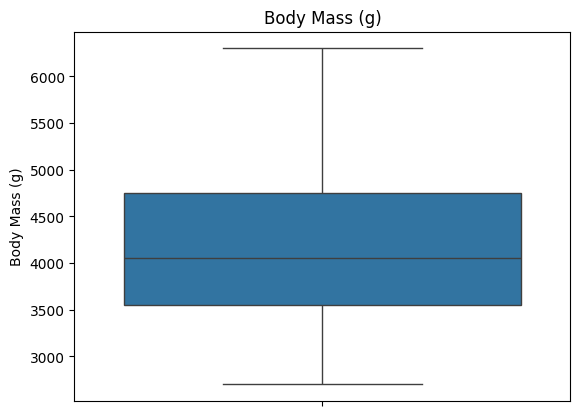

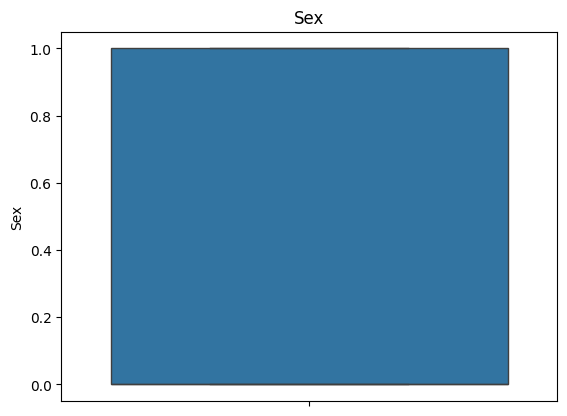

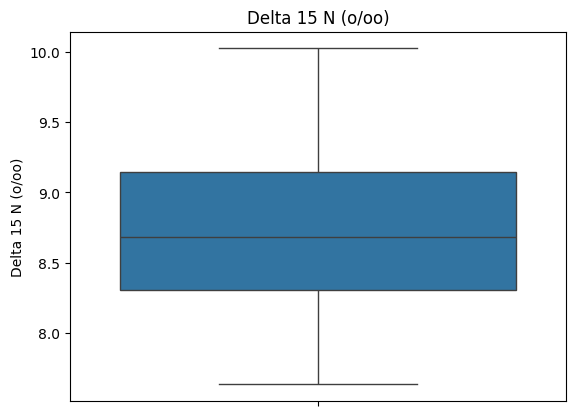

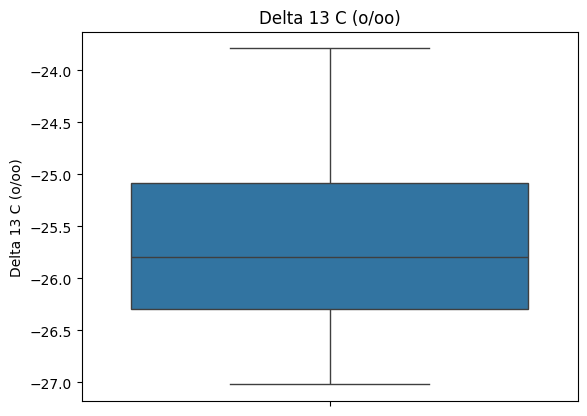

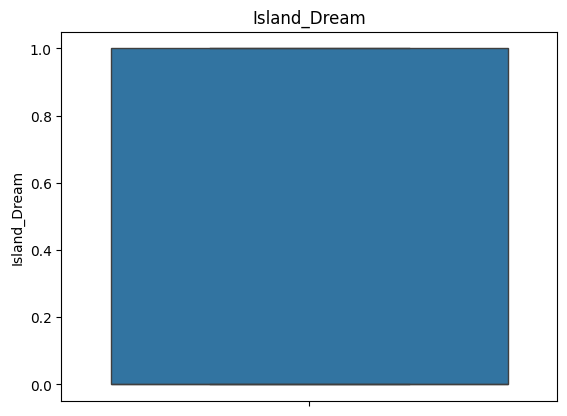

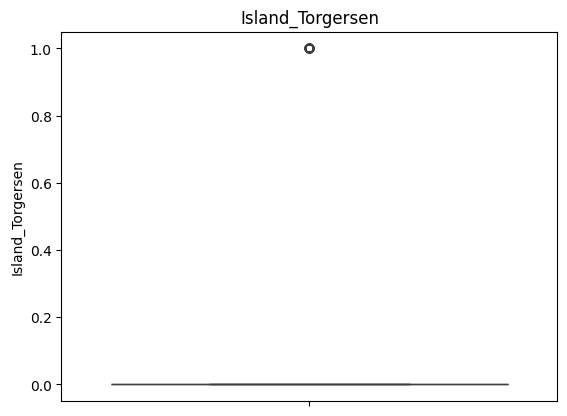

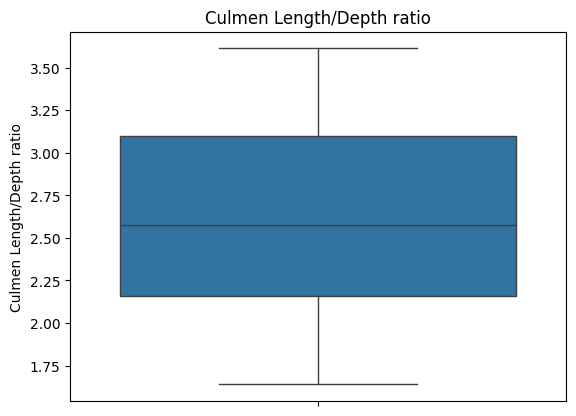

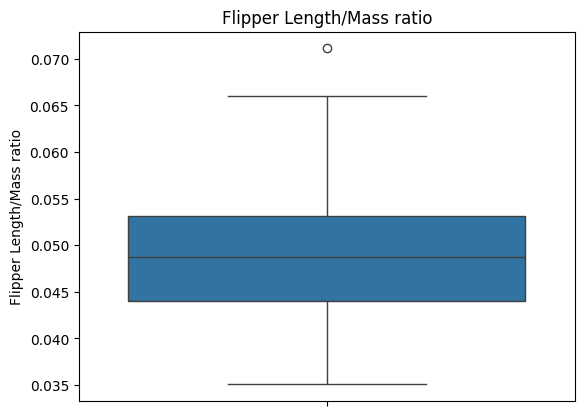

In [32]:
for i in df_visFRQ.columns :
    if is_numeric_dtype(df_visFRQ[i]) :
        plt.figure()
        plt.title(i)
        sns.boxplot(df_visFRQ[i])

In [33]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Individual ID',
       'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Island_Dream',
       'Island_Torgersen', 'Culmen Length/Depth ratio',
       'Flipper Length/Mass ratio'],
      dtype='str')

In [34]:
categorial_cols = ['Clutch Completion','Clutch Completion','Sex',  'Island_Dream', 'Island_Torgersen',
        "Species" ]
df_cat = df[categorial_cols]
df_cat

,Clutch Completion,Clutch Completion,Sex,Island_Dream,Island_Torgersen,Species
0,Yes,Yes,0,0,1,Adelie Penguin (Pygoscelis adeliae)
1,Yes,Yes,1,0,1,Adelie Penguin (Pygoscelis adeliae)
2,Yes,Yes,1,0,1,Adelie Penguin (Pygoscelis adeliae)
4,Yes,Yes,1,0,1,Adelie Penguin (Pygoscelis adeliae)
5,Yes,Yes,0,0,1,Adelie Penguin (Pygoscelis adeliae)
...,...,...,...,...,...,...
338,No,No,1,0,0,Gentoo penguin (Pygoscelis papua)
340,Yes,Yes,1,0,0,Gentoo penguin (Pygoscelis papua)
341,Yes,Yes,0,0,0,Gentoo penguin (Pygoscelis papua)
342,Yes,Yes,1,0,0,Gentoo penguin (Pygoscelis papua)


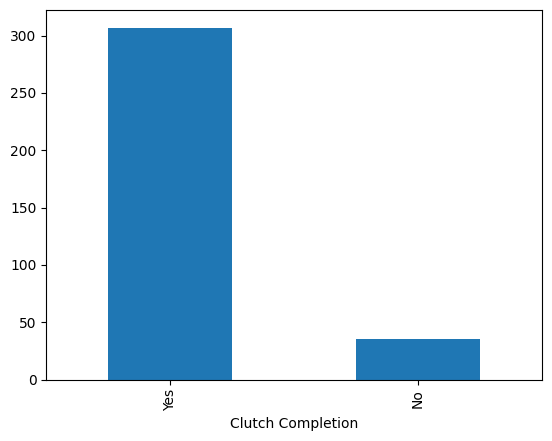

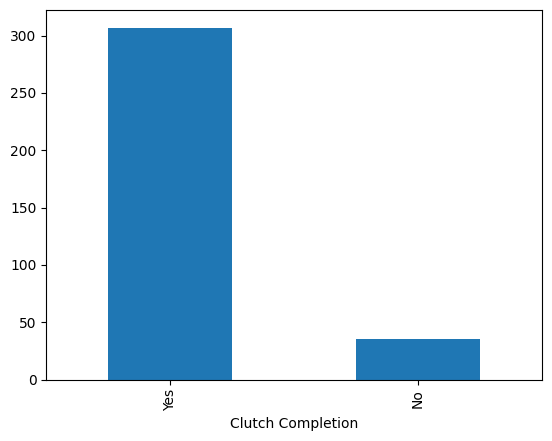

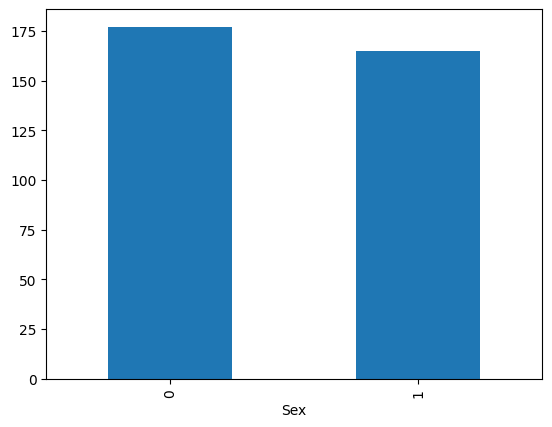

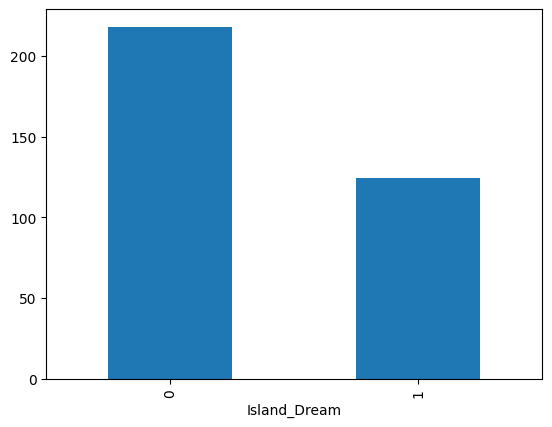

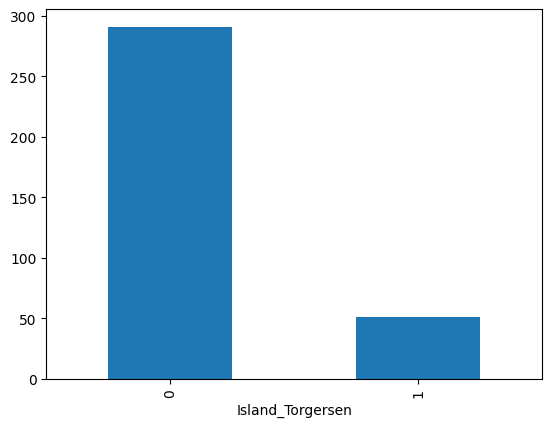

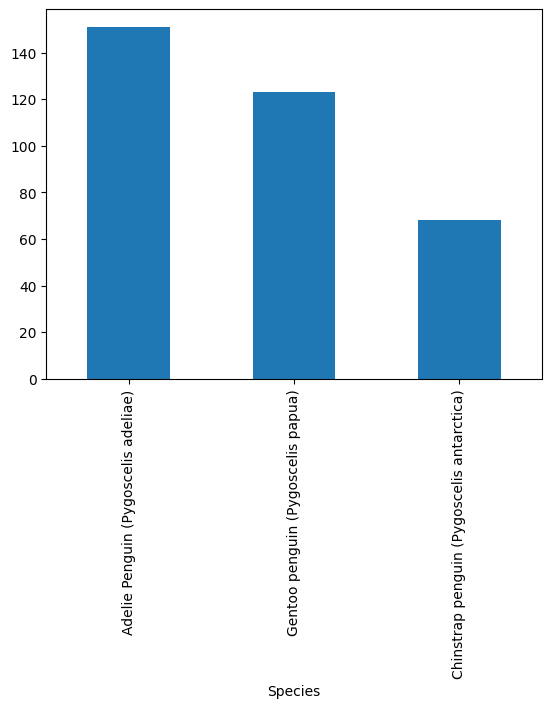

In [35]:
for i in df_cat.columns :
    plt.figure()
    df[i].value_counts().plot(kind='bar')

<Axes: >

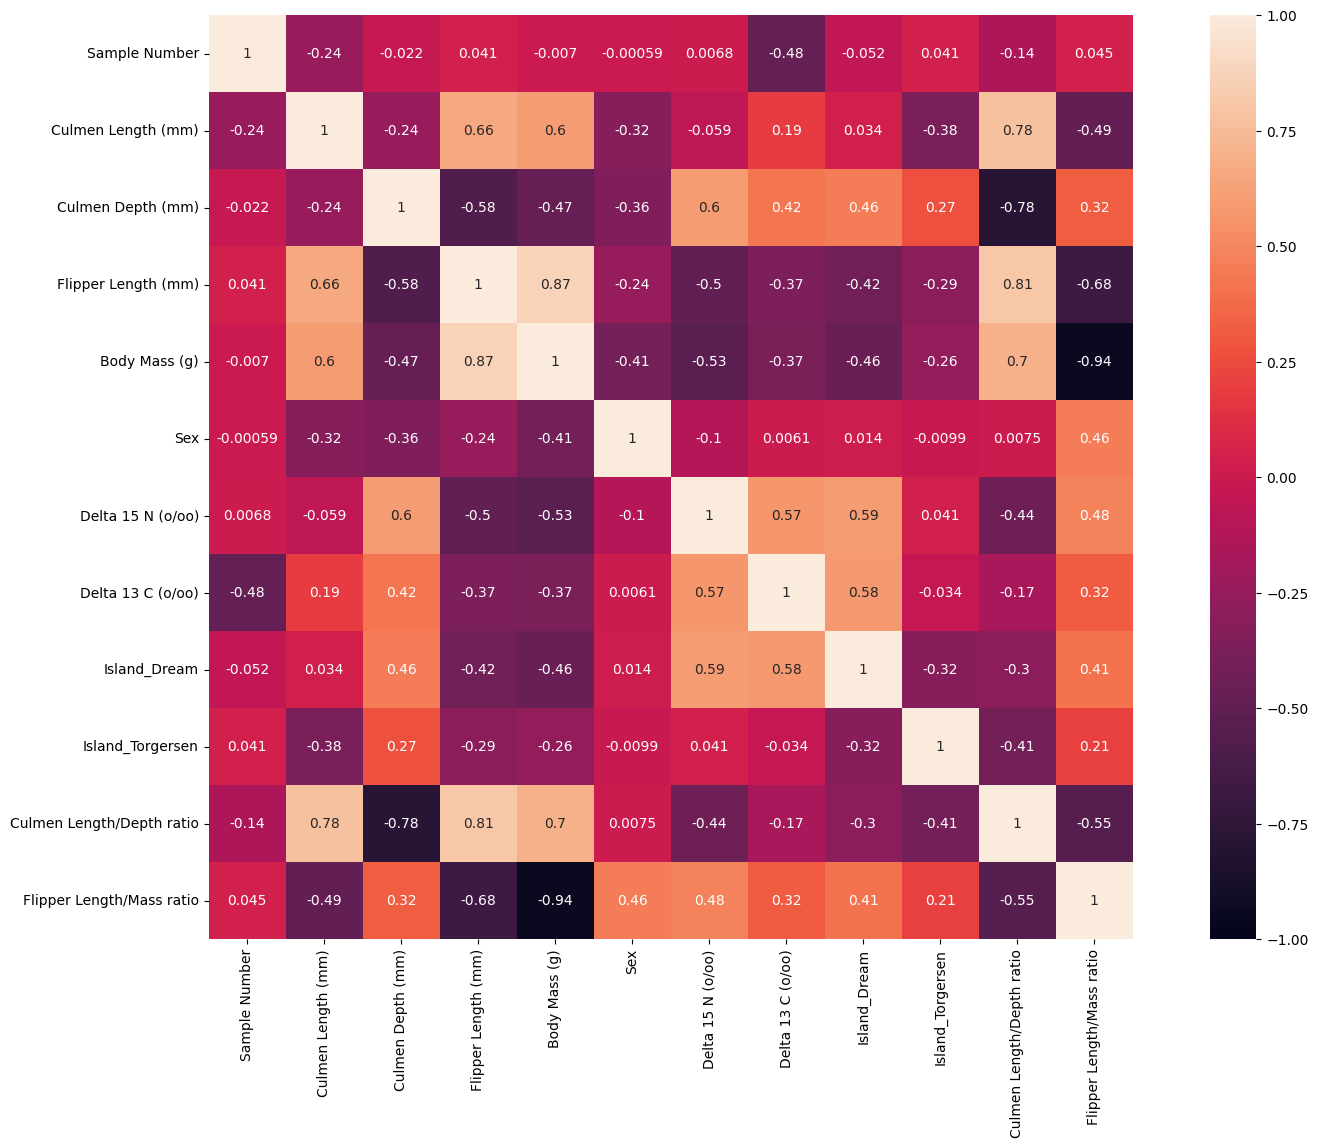

In [36]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, 
            annot=True,        
            vmin=-1, vmax=1,
            square=True 
           )


Итоги :
1) длинна ласт имеет положительную корелляцию с массой тела, и можно сказать что для пингвинов характерно что чем больше масс тем больше ласты(как будто очевидно кншн. но на данных проверить стоит)
2) одно из самых сложных решений при EDA это как восстанавливать потерянные данные
3) для визуализации пропусков очень удобно использовать библиотеку missingnno
4) стоит сказать что у пингвинов разных видов могут по разному коррелировать признаки(как можно увидеть на матрице корреляции),что открывает почву для обучения модели на задачу классификации(устанавливать на основе числовых параметров к какому виду относится пингвин)
5) пол, вопреки первоначальной теории не так сильно влияет на масссу, как предполагалось, но что очень сильно влияет так это принадлежность к определенному виду
6) выбирать как кодировать категориальные признаки это целое отдельное исскуство, условно OHE стоит использовать только при наличии небольшого числа категории, иначе размерность данных стремиться к катастрофе, и так с каждым разным видом, вообще как-будто при работе с данными самое слодное это принятие определенных решений, какие данные выкинуть, какую кодировку применить и т.п.
7) Данные между собой очень сложно могут взаимодействовать, здесь остров влияет на вид, которые вляиет на массу, которая влияет на другие параметры, и за такими взаимодействиями очень слонжо следить человеку


стоит сказать про использование моделей машинного обучения
1) прекрасно подходит датасет для задач классификации, на основе признаков узнать к какому виду относится пингвинов
2) можно использовать различные алгоритмы классифкации(в следующем домашнем задании использовать буду KNN на этом датасете)
3) в результате работы в 3м ДЗ, немного изменил подход к инженерингу фичей 



по нейронкам, пользовался только гуглом и один раз спросил за feaure engeniring , регулярно пользовался гуглом для команд на питоне

In [37]:
df.to_csv("Crak.csv",index = False)